=== RÉSULTATS DE LA SIMULATION ===
Temps simulé              : 120.0 secondes
Volume transféré          : 1495.0 ml  (1.49 litres)
Pression finale réservoir 1 : 326986.6 kPa
Pression finale réservoir 2 : 0.0 kPa
ΔP final                  : 326986.6 kPa


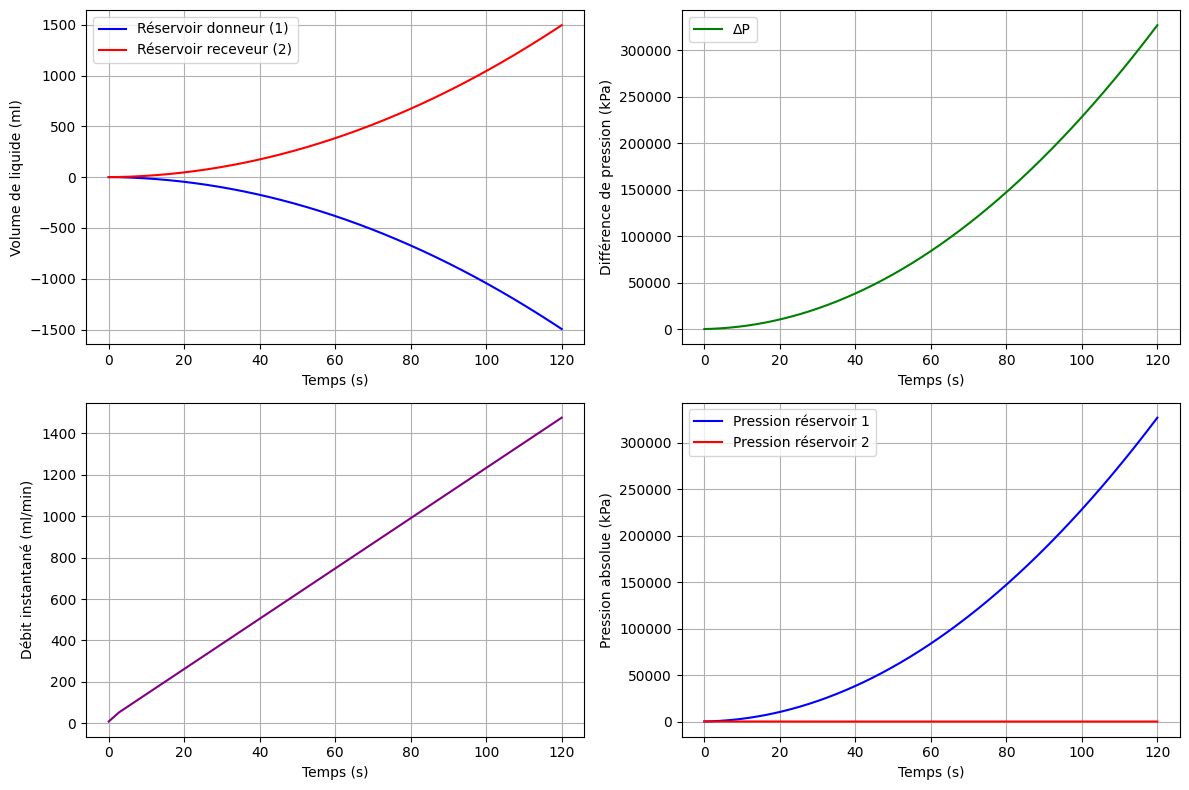

In [63]:
import numpy as np
from scipy.integrate import solve_ivp
import matplotlib.pyplot as plt
# ====================== PARAMÈTRES PHYSIQUES ======================
rho = 1050.0          # densité du savon liquide (kg/m³) ≈ 1050
Cd = 0.62             # coefficient de décharge (orifice réel)
D_orifice = 0.008     # diamètre de l'ouverture entre les deux flacons (8 mm)
A = np.pi * (D_orifice / 2)**2   # section de l'orifice (m²)
# Volumes des réservoirs (capacité totale)
V_tank1 = 0.0015      # 1.5 litre - réservoir qui donne
V_tank2 = 0.0015      # 1.5 litre - réservoir receveur
# Conditions initiales
V1_init = 0.0010      # 1.0 litre de savon dans le réservoir plein
V2_init = 0.0002      # 0.2 litre dans le receveur (presque vide)
P_atm = 101325.0      # pression atmosphérique (Pa)
P1_init = P_atm + 8000   # surpression initiale dans le flacon plein (+80 mbar)
P2_init = P_atm - 3000   # dépression après avoir pressé pour chasser l'air (-30 mbar)
# ====================== ÉQUATIONS DIFFÉRENTIELLES ======================
def transfert(t, y, A, rho, Cd, V_tank1, V_tank2):
    V_liquide1, P1, V_liquide2, P2 = y

    V_gas1 = V_tank1 - V_liquide1   # volume d'air dans réservoir 1
    V_gas2 = V_tank2 - V_liquide2   # volume d'air dans réservoir 2

    deltaP = P1 - P2

    # Débit volumique (formule de Torricelli avec coefficient de décharge)
    if deltaP > 0:
        Q = Cd * A * np.sqrt(2 * deltaP / rho)   # m³/s
    else:
        Q = 0.0

    # Dérivées
    dV1_dt = -Q
    dV2_dt = +Q

    # Évolution de la pression (loi des gaz parfaits isotherme : P·V = cte)
    dP1_dt = - (P1 / V_gas1) * dV1_dt if V_gas1 > 1e-8 else 0
    dP2_dt = - (P2 / V_gas2) * dV2_dt if V_gas2 > 1e-8 else 0

    return [dV1_dt, dP1_dt, dV2_dt, dP2_dt]
# ====================== SIMULATION ======================
y0 = [V1_init, P1_init, V2_init, P2_init]
sol = solve_ivp(
    transfert,
    t_span=(0, 120),           # simulation sur 2 minutes
    y0=y0,
    args=(A, rho, Cd, V_tank1, V_tank2),
    method='RK45',
    t_eval=np.linspace(0, 120, 2000),
    rtol=1e-6
)
# ====================== AFFICHAGE DES RÉSULTATS ======================
V_transfere = sol.y[2][-1] - V2_init
print("=== RÉSULTATS DE LA SIMULATION ===")
print(f"Temps simulé              : {sol.t[-1]:.1f} secondes")
print(f"Volume transféré          : {V_transfere*1000:.1f} ml  ({V_transfere*1000/1000:.2f} litres)")
print(f"Pression finale réservoir 1 : {sol.y[1][-1]/1000:.1f} kPa")
print(f"Pression finale réservoir 2 : {sol.y[3][-1]/1000:.1f} kPa")
print(f"ΔP final                  : {(sol.y[1][-1] - sol.y[3][-1])/1000:.1f} kPa")
# ====================== GRAPHIQUES ======================
plt.figure(figsize=(12, 8))
plt.subplot(2, 2, 1)
plt.plot(sol.t, sol.y[0]*1000, label='Réservoir donneur (1)', color='blue')
plt.plot(sol.t, sol.y[2]*1000, label='Réservoir receveur (2)', color='red')
plt.xlabel('Temps (s)')
plt.ylabel('Volume de liquide (ml)')
plt.legend()
plt.grid(True)
plt.subplot(2, 2, 2)
plt.plot(sol.t, (sol.y[1] - sol.y[3])/1000, 'g-', label='ΔP')
plt.xlabel('Temps (s)')
plt.ylabel('Différence de pression (kPa)')
plt.legend()
plt.grid(True)
plt.subplot(2, 2, 3)
debit_ml_s = Cd * A * np.sqrt(2 * np.maximum(sol.y[1] - sol.y[3], 0) / rho) * 1000
plt.plot(sol.t, debit_ml_s * 60, 'purple')
plt.xlabel('Temps (s)')
plt.ylabel('Débit instantané (ml/min)')
plt.grid(True)
plt.subplot(2, 2, 4)
plt.plot(sol.t, sol.y[1]/1000, label='Pression réservoir 1', color='blue')
plt.plot(sol.t, sol.y[3]/1000, label='Pression réservoir 2', color='red')
plt.xlabel('Temps (s)')
plt.ylabel('Pression absolue (kPa)')
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

In [ ]:

# ====================== PARAMÈTRES PHYSIQUES ======================
rho = 1050.0          # densité du savon liquide (kg/m³) ≈ 1050
Cd = 0.62             # coefficient de décharge (orifice réel)
D_orifice = 0.008     # diamètre de l'ouverture entre les deux flacons (8 mm)
A = np.pi * (D_orifice / 2)**2   # section de l'orifice (m²)

# Volumes des réservoirs (capacité totale)
V_tank1 = 0.0015      # 1.5 litre - réservoir qui donne
V_tank2 = 0.0015      # 1.5 litre - réservoir receveur

# Conditions initiales
V1_init = 0.0010      # 1.0 litre de savon dans le réservoir plein
V2_init = 0.0002      # 0.2 litre dans le receveur (presque vide)

P_atm = 101325.0      # pression atmosphérique (Pa)
P1_init = P_atm + 8000   # surpression initiale dans le flacon plein (+80 mbar)
P2_init = P_atm - 3000   # dépression après avoir pressé pour chasser l'air (-30 mbar)

# ====================== ÉQUATIONS DIFFÉRENTIELLES ======================
def transfert(t, y, A, rho, Cd, V_tank1, V_tank2):
    V_liquide1, P1, V_liquide2, P2 = y
    
    V_gas1 = V_tank1 - V_liquide1   # volume d'air dans réservoir 1
    V_gas2 = V_tank2 - V_liquide2   # volume d'air dans réservoir 2
    
    deltaP = P1 - P2
    
    # Débit volumique (formule de Torricelli avec coefficient de décharge)
    if deltaP > 0:
        Q = Cd * A * np.sqrt(2 * deltaP / rho)   # m³/s
    else:
        Q = 0.0
    
    # Dérivées
    dV1_dt = -Q
    dV2_dt = +Q
    
    # Évolution de la pression (loi des gaz parfaits isotherme : P·V = cte)
    dP1_dt = (P1 / V_gas1) * dV1_dt if V_gas1 > 1e-8 else 0
    dP2_dt = (P2 / V_gas2) * dV2_dt if V_gas2 > 1e-8 else 0
    
    return [dV1_dt, dP1_dt, dV2_dt, dP2_dt]

def transfert(t, y, A, rho, Cd, V_tank1):
    V_liquide1, P1 = y
    
    V_gas1 = V_tank1 - V_liquide1
    
    deltaP = P1 - P_atm  # réservoir 2 toujours à P_atm
    
    if deltaP > 0:
        Q = Cd * A * np.sqrt(2 * deltaP / rho)
    else:
        Q = 0.0
    
    dV1_dt = -Q
    # Gaz du réservoir 1 se détend → pression baisse
    dP1_dt = (P1 / V_gas1) * dV1_dt if V_gas1 > 1e-8 else 0

    return [dV1_dt, dP1_dt]

P_vide = 0.0  # vide spatial absolu

def transfert(t, y, A, rho, Cd, V_tank1):
    V_liquide1, P1 = y
    
    V_gas1 = V_tank1 - V_liquide1
    
    deltaP = P1 - P_vide  # = P1 entièrement
    
    if deltaP > 0 and V_liquide1 > 0:
        Q = Cd * A * np.sqrt(2 * deltaP / rho)
    else:
        Q = 0.0
    
    dV1_dt = -Q
    dP1_dt = (P1 / V_gas1) * dV1_dt if V_gas1 > 1e-8 else 0

    return [dV1_dt, dP1_dt]

# ====================== SIMULATION ======================
#y0 = [V1_init, P1_init, V2_init, P2_init]

# Conditions initiales
y0 = [V1_init, P1_init]

sol = solve_ivp(
    transfert,
    t_span=(0, 120),
    y0=y0,
    args=(A, rho, Cd, V_tank1),
    method='RK45',
    t_eval=np.linspace(0, 120, 2000),
    rtol=1e-6
)
'''
sol = solve_ivp(
    transfert,
    t_span=(0, 120),           # simulation sur 2 minutes
    y0=y0,
    args=(A, rho, Cd, V_tank1, V_tank2),
    method='RK45',
    t_eval=np.linspace(0, 120, 2000),
    rtol=1e-6
)
'''


"\nsol = solve_ivp(\n    transfert,\n    t_span=(0, 120),           # simulation sur 2 minutes\n    y0=y0,\n    args=(A, rho, Cd, V_tank1, V_tank2),\n    method='RK45',\n    t_eval=np.linspace(0, 120, 2000),\n    rtol=1e-6\n)\n"

In [54]:

# ====================== AFFICHAGE DES RÉSULTATS ======================
#V_transfere = sol.y[2][-1] - V2_init
# Volume transféré = ce qui est sorti du réservoir 1
V_transfere = V1_init - sol.y[0]
V_receveur = V2_init + V_transfere
V_transfere, V_receveur

(array([0.00000000e+00, 2.66448327e-05, 5.26316717e-05, ...,
        1.00002768e-03, 1.00002768e-03, 1.00002768e-03], shape=(2000,)),
 array([0.0002    , 0.00022664, 0.00025263, ..., 0.00120003, 0.00120003,
        0.00120003], shape=(2000,)))

In [55]:
sol.y

array([[ 1.00000000e-03,  9.73355167e-04,  9.47368328e-04, ...,
        -2.76802759e-08, -2.76802759e-08, -2.76802759e-08],
       [ 1.09325000e+05,  1.03793604e+05,  9.89129268e+04, ...,
         3.64411026e+04,  3.64411026e+04,  3.64411026e+04]],
      shape=(2, 2000))

In [56]:
sol.y[1][-1]/1000

np.float64(36.44110258898847)

In [57]:

print("=== RÉSULTATS DE LA SIMULATION ===")
print(f"Temps simulé              : {sol.t[-1]:.1f} secondes")
print(f"Volume transféré          : {V_transfere[-1]*1000:.1f} ml  ({V_transfere[-1]*1000/1000:.2f} litres)")
print(f"Pression finale réservoir 1 : {sol.y[1][-1]/1000:.1f} kPa")

print(f"Pression finale réservoir 2 : {sol.y[1][-1]/1000:.1f} kPa")
print(f"ΔP final                  : {(sol.y[1][-1] - sol.y[1][0])/1000:.1f} kPa")


=== RÉSULTATS DE LA SIMULATION ===
Temps simulé              : 120.0 secondes
Volume transféré          : 1.0 ml  (0.00 litres)
Pression finale réservoir 1 : 36.4 kPa
Pression finale réservoir 2 : 36.4 kPa
ΔP final                  : -72.9 kPa


In [58]:
sol

  message: The solver successfully reached the end of the integration interval.
  success: True
   status: 0
        t: [ 0.000e+00  6.003e-02 ...  1.199e+02  1.200e+02]
        y: [[ 1.000e-03  9.734e-04 ... -2.768e-08 -2.768e-08]
            [ 1.093e+05  1.038e+05 ...  3.644e+04  3.644e+04]]
      sol: None
 t_events: None
 y_events: None
     nfev: 194
     njev: 0
      nlu: 0

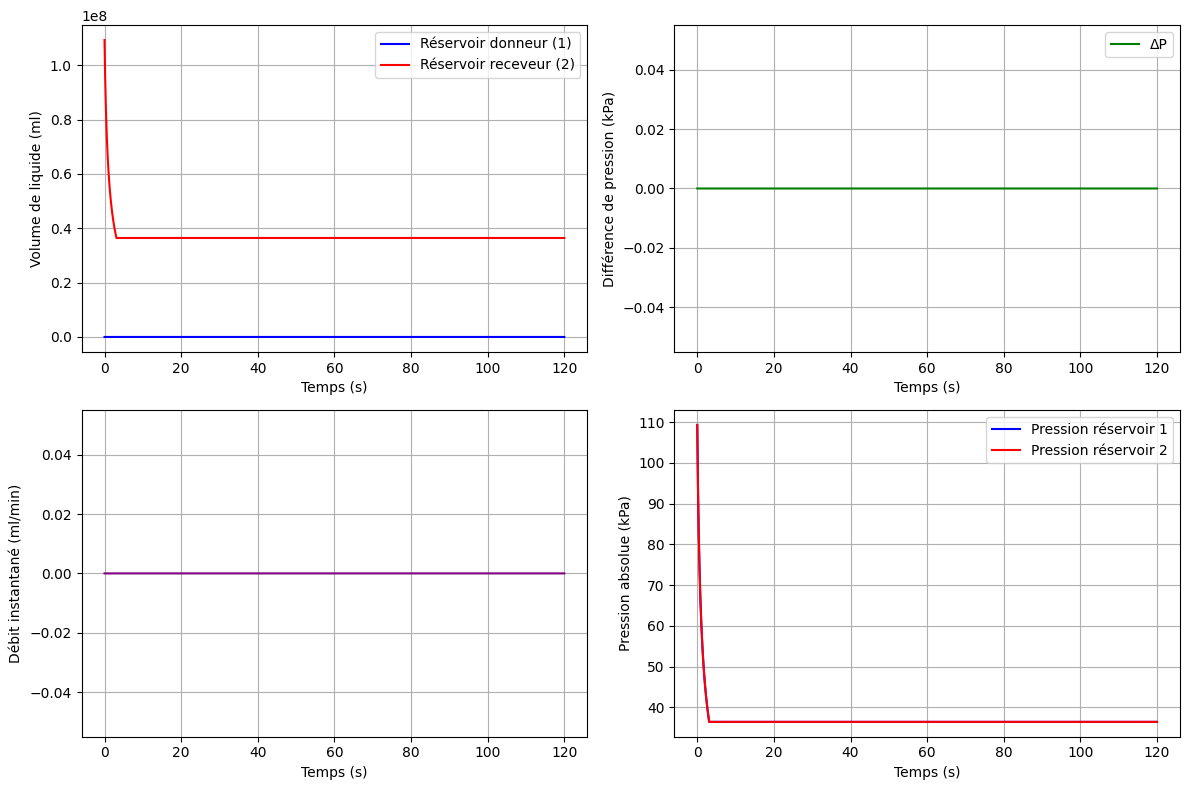

In [62]:

# ====================== GRAPHIQUES ======================
plt.figure(figsize=(12, 8))

plt.subplot(2, 2, 1)
plt.plot(sol.t, sol.y[0]*1000, label='Réservoir donneur (1)', color='blue')
plt.plot(sol.t, sol.y[1]*1000, label='Réservoir receveur (2)', color='red')
plt.xlabel('Temps (s)')
plt.ylabel('Volume de liquide (ml)')
plt.legend()
plt.grid(True)

plt.subplot(2, 2, 2)
plt.plot(sol.t, (sol.y[1] - sol.y[1])/1000, 'g-', label='ΔP')
plt.xlabel('Temps (s)')
plt.ylabel('Différence de pression (kPa)')
plt.legend()
plt.grid(True)

plt.subplot(2, 2, 3)
debit_ml_s = Cd * A * np.sqrt(2 * np.maximum(sol.y[1] - sol.y[1], 0) / rho) * 1000
plt.plot(sol.t, debit_ml_s * 60, 'purple')
plt.xlabel('Temps (s)')
plt.ylabel('Débit instantané (ml/min)')
plt.grid(True)

plt.subplot(2, 2, 4)
plt.plot(sol.t, sol.y[1]/1000, label='Pression réservoir 1', color='blue')
plt.plot(sol.t, sol.y[-1]/1000, label='Pression réservoir 2', color='red')
plt.xlabel('Temps (s)')
plt.ylabel('Pression absolue (kPa)')
plt.legend()
plt.grid(True)

plt.tight_layout()
plt.show()

In [78]:
import numpy as np
from scipy.integrate import solve_ivp
import matplotlib.pyplot as plt

# ====================== PARAMÈTRES (ajustés pour être réaliste) ======================
rho = 1050.0                    # densité savon liquide
Cd = 0.65                       # coefficient de décharge
D_orifice = 0.0009               # diamètre réduit à 4 mm → débit plus lent
A = np.pi * (D_orifice / 2)**2

V_tank = 0.0015                 # capacité de chaque flacon = 1.5 L

V1_init = 0.0010                # 1000 ml dans le flacon plein
V2_init = 0.00015                # 100 ml dans le receveur

P_atm = 101325.0
P1_init = P_atm + 12000         # +120 mbar (on presse le flacon plein)
P2_init = P_atm - 12000          # -80 mbar (on presse fort le receveur pour chasser l'air)

# ====================== FONCTION (avec protections) ======================
def transfert(t, y, A, rho, Cd, V_tank):
    V1, P1, V2, P2 = y
    
    V1 = max(0.0, min(V1, V_tank))
    V2 = max(0.0, min(V2, V_tank))
    
    V_gas1 = V_tank - V1
    V_gas2 = V_tank - V2
    
    deltaP = P1 - P2
    
    # === AMÉLIORATION IMPORTANTE ===
    if deltaP < 1.0:          # seuil de 1 Pa (très petite valeur)
        Q = 0.0
    else:
        Q = Cd * A * np.sqrt(2 * deltaP / rho)
    
    # Protection supplémentaire quand V1 est presque vide
    if V1 < 0.00003:
        Q = min(Q, V1 / 0.01)
    
    dV1_dt = -Q
    dV2_dt = +Q
    
    dP1_dt = - (P1 / V_gas1) * Q if V_gas1 > 1e-8 else 0
    dP2_dt = + (P2 / V_gas2) * Q if V_gas2 > 1e-8 else 0
    
    return [dV1_dt, dP1_dt, dV2_dt, dP2_dt]

def transfert(t, y, A, rho, Cd, V_tank, P2_fixed):
    V1, P1, V2 = y                  # On ne suit plus P2 (elle est fixe)
    
    # Protections
    V1 = max(0.0, min(V1, V_tank))
    V2 = max(0.0, min(V2, V_tank))
    
    V_gas1 = V_tank - V1
    
    deltaP = P1 - P2_fixed          # P2 est fixe !
    
    Q = 0.0
    if deltaP > 10.0 and V1 > 0.00001:          # seuil pour éviter bruit numérique
        Q = Cd * A * np.sqrt(2 * deltaP / rho)
    
    # Limitation quand presque vide
    if V1 < 0.00003:
        Q = min(Q, V1 / 0.01)
    
    dV1_dt = -Q
    dV2_dt = +Q
    
    # Seulement le réservoir 1 voit sa pression changer
    dP1_dt = - (P1 / V_gas1) * Q if V_gas1 > 1e-8 else 0
    
    return [dV1_dt, dP1_dt, dV2_dt]

# ====================== SIMULATION ======================
y0 = [V1_init, P1_init, V2_init, P2_init]

sol = solve_ivp(
    transfert,
    t_span=(0, 120),
    y0=y0,
    args=(A, rho, Cd, V_tank),
    method='RK45',
    t_eval=np.linspace(0, 120, 1500),
    rtol=1e-6,
    atol=1e-9
)

# ====================== AFFICHAGE RÉSULTATS ======================
print(f"Volume transféré final : { (sol.y[2][-1] - V2_init)*1000 :.0f} ml")
print(f"Volume restant réservoir 1 : {sol.y[0][-1]*1000 :.0f} ml")
print(f"ΔP final : {(sol.y[1][-1] - sol.y[3][-1])/1000 :.1f} kPa")

# ====================== GRAPHIOUES CLAIRS ======================
plt.figure(figsize=(14, 10))

plt.subplot(2, 2, 1)
plt.plot(sol.t, sol.y[0]*1000, label='Réservoir 1 (donneur)', linewidth=2)
plt.plot(sol.t, sol.y[2]*1000, label='Réservoir 2 (receveur)', linewidth=2)
plt.xlabel('Temps (secondes)')
plt.ylabel('Volume de liquide (ml)')
plt.title('Évolution des volumes')
plt.legend()
plt.grid(True)

plt.subplot(2, 2, 2)
plt.plot(sol.t, (sol.y[1] - sol.y[3])/1000, 'g', linewidth=2)
plt.xlabel('Temps (secondes)')
plt.ylabel('ΔP (kPa)')
plt.title('Différence de pression')
plt.grid(True)

plt.subplot(2, 2, 3)
plt.plot(sol.t, sol.y[1]/1000, label='Pression réservoir 1', color='blue')
plt.plot(sol.t, sol.y[3]/1000, label='Pression réservoir 2', color='red')
plt.xlabel('Temps (secondes)')
plt.ylabel('Pression (kPa)')
plt.title('Évolution des pressions')
plt.legend()
plt.grid(True)

plt.subplot(2, 2, 4)
debit_ml_s = Cd * A * np.sqrt(2 * np.maximum(sol.y[1]-sol.y[3], 0)/rho) * 1000
plt.plot(sol.t, debit_ml_s*60, 'purple', linewidth=2)
plt.xlabel('Temps (secondes)')
plt.ylabel('Débit (ml/min)')
plt.title('Débit instantané')
plt.grid(True)

plt.tight_layout()
plt.show()

TypeError: transfert() missing 1 required positional argument: 'P2_fixed'

Volume final réservoir 1 : 0.0 ml
Volume final réservoir 2 : 1.1 ml
Volume transféré         : 1.0 ml


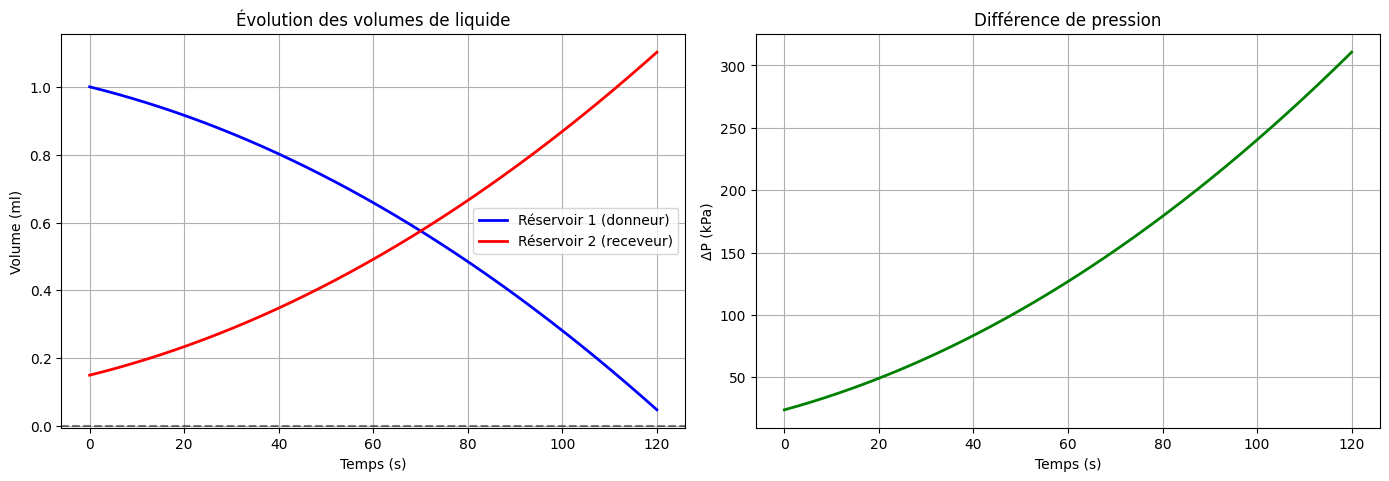

In [ ]:
import numpy as np
from scipy.integrate import solve_ivp
import matplotlib.pyplot as plt

# ====================== PARAMÈTRES ======================
rho = 1050.0
Cd = 0.65
D_orifice = 0.0015          # encore un peu réduit pour mieux voir sur 120s
A = np.pi * (D_orifice / 2)**2

V_tank = 0.0015             # 1.5 L

V1_init = 0.0010            # 1000 ml
V2_init = 0.00015           # 150 ml

P_atm = 101325.0
P1_init = P_atm + 15000     # on presse un peu plus le donneur
P2_init = P_atm - 9000      # on presse bien le receveur

# ====================== FONCTION AMÉLIORÉE ======================
def transfert(t, y, A, rho, Cd, V_tank):
    V1, P1, V2, P2 = y
    
    # Protection stricte des volumes AVANT calcul
    V1 = max(0.0, min(V1, V_tank))
    V2 = max(0.0, min(V2, V_tank))
    
    V_gas1 = V_tank - V1
    V_gas2 = V_tank - V2
    
    deltaP = P1 - P2
    Q = 0.0
    if deltaP > 0 and V1 > 0:
        Q = Cd * A * np.sqrt(2 * deltaP / rho)
    
    # On limite fortement le débit quand on approche de zéro
    if V1 < 0.00001:        # moins de 10 ml restant
        Q = min(Q, V1 / 0.01)  # on ne peut pas enlever plus que ce qui reste en 0.01s
    
    dV1_dt = -Q
    dV2_dt = +Q
    
    dP1_dt = - (P1 / V_gas1) * dV1_dt if V_gas1 > 1e-8 else 0
    dP2_dt = - (P2 / V_gas2) * dV2_dt if V_gas2 > 1e-8 else 0
    
    return [dV1_dt, dP1_dt, dV2_dt, dP2_dt]

# ====================== FONCTION CORRIGÉE ======================
def transfert(t, y, A, rho, Cd, V_tank):
    V1, P1, V2, P2 = y
    
    # Protections
    V1 = max(0.0, min(V1, V_tank))
    V2 = max(0.0, min(V2, V_tank))
    
    V_gas1 = V_tank - V1
    V_gas2 = V_tank - V2
    
    deltaP = P1 - P2
    
    Q = 0.0
    if deltaP > 0 and V1 > 0.00001:
        Q = Cd * A * np.sqrt(2 * deltaP / rho)
    
    # Limite le débit près de zéro
    if V1 < 0.00003:
        Q = min(Q, V1 / 0.01)
    
    dV1_dt = -Q
    dV2_dt = +Q
    
    # === FORMULES PHYSIQUEMENT CORRECTES ===
    dP1_dt =  (P1 / V_gas1) * Q if V_gas1 > 1e-8 else 0     # Pression 1 diminue
    dP2_dt = -(P2 / V_gas2) * Q if V_gas2 > 1e-8 else 0     # Pression 2 augmente
    
    return [dV1_dt, dP1_dt, dV2_dt, dP2_dt]

# ====================== SIMULATION ======================
y0 = [V1_init, P1_init, V2_init, P2_init]

sol = solve_ivp(
    transfert,
    t_span=(0, 120),
    y0=y0,
    args=(A, rho, Cd, V_tank),
    method='LSODA',           # méthode plus stable pour ce type de problème
    t_eval=np.linspace(0, 120, 2000),
    rtol=1e-8,
    atol=1e-10
)

# ====================== RÉSULTATS ======================
print(f"Volume final réservoir 1 : {sol.y[0][-1]*1000:.1f} ml")
print(f"Volume final réservoir 2 : {sol.y[2][-1]*1000:.1f} ml")
print(f"Volume transféré         : {(sol.y[2][-1] - V2_init)*1000:.1f} ml")

# Graphiques
plt.figure(figsize=(14, 9))

plt.subplot(2, 2, 1)
plt.plot(sol.t, sol.y[0]*1000, label='Réservoir 1 (donneur)', color='blue', linewidth=2)
plt.plot(sol.t, sol.y[2]*1000, label='Réservoir 2 (receveur)', color='red', linewidth=2)
plt.axhline(y=0, color='black', linestyle='--', alpha=0.5)
plt.xlabel('Temps (s)')
plt.ylabel('Volume (ml)')
plt.title('Évolution des volumes de liquide')
plt.legend()
plt.grid(True)

plt.subplot(2, 2, 2)
plt.plot(sol.t, (sol.y[1] - sol.y[3])/1000, 'g', linewidth=2)
plt.xlabel('Temps (s)')
plt.ylabel('ΔP (kPa)')
plt.title('Différence de pression')
plt.grid(True)

plt.tight_layout()
plt.show()

Volume transféré final : 0.1 ml
Pression finale réservoir 1 : 101.33 kPa
Pression réservoir 2 (fixe) : 101.33 kPa


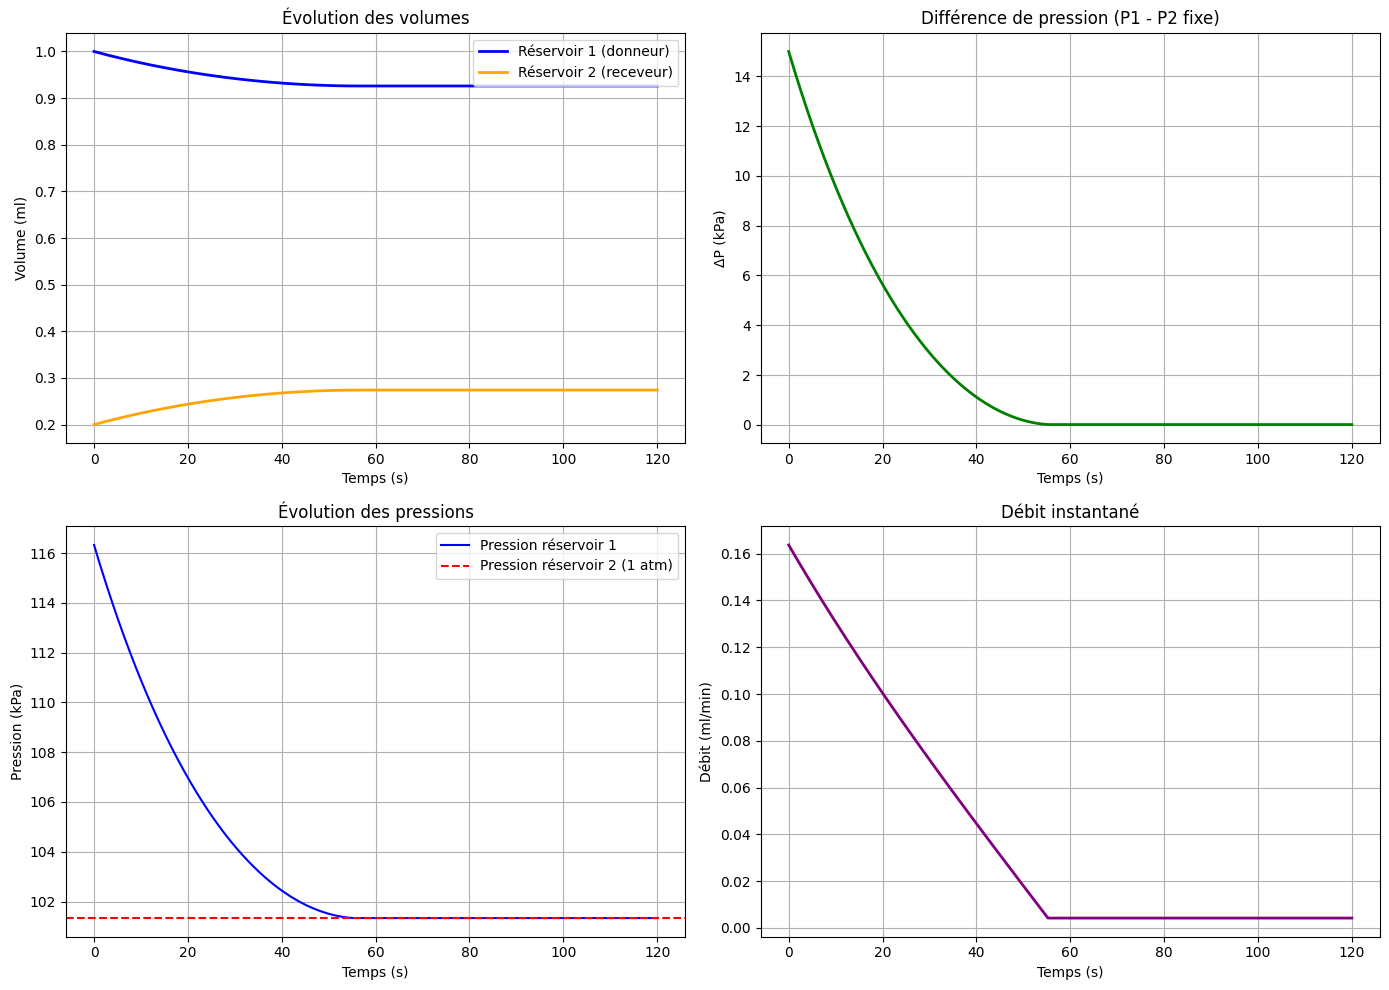

In [ ]:
import numpy as np
from scipy.integrate import solve_ivp
import matplotlib.pyplot as plt

# ====================== PARAMÈTRES RECOMMANDÉS POUR ~90% ======================
rho = 1050.0
Cd = 0.65
D_orifice = 3.5                 # ← 3.5 mm recommandé
A = np.pi * (D_orifice / 2000)**2

V_tank = 0.0015
V1_init = 0.0010                # 1000 ml
V2_init = 0.0002                # 200 ml

P_atm = 101325.0
P1_init = P_atm + 14000         # +14 kPa (bon réglage)

P2_fixed = P_atm                # venting à l'air libre

# ====================== FONCTION ======================
def transfert(t, y, A, rho, Cd, V_tank, P2_fixed):
    V1, P1, V2 = y
    V1 = max(0.0, min(V1, V_tank))
    V2 = max(0.0, min(V2, V_tank))
    V_gas1 = V_tank - V1
    
    deltaP = P1 - P2_fixed
    Q = 0.0
    if deltaP > 10 and V1 > 0.00001:
        Q = Cd * A * np.sqrt(2 * deltaP / rho)
    if V1 < 0.00003:
        Q = min(Q, V1 / 0.01)
    
    dV1_dt = -Q
    dV2_dt = +Q
    dP1_dt = - (P1 / V_gas1) * Q if V_gas1 > 1e-8 else 0
    
    return [dV1_dt, dP1_dt, dV2_dt]

# Simulation
y0 = [V1_init, P1_init, V2_init]
sol = solve_ivp(transfert, (0, 120), y0, args=(A, rho, Cd, V_tank, P2_fixed),
                method='LSODA', t_eval=np.linspace(0, 120, 1500))

volume_transfere = (sol.y[2][-1] - V2_init) * 1000
print(f"Volume transféré : {volume_transfere:.1f} ml  →  {volume_transfere/10:.1f} %")

# Graphiques (identiques à avant)
# ... (je peux te les remettre si besoin)

# ====================== SIMULATION ======================
y0 = [V1_init, P1_init, V2_init]

sol = solve_ivp(
    transfert,
    t_span=(0, 120),
    y0=y0,
    args=(A, rho, Cd, V_tank, P2_fixed),
    method='LSODA',
    t_eval=np.linspace(0, 120, 1500),
    rtol=1e-8,
    atol=1e-10
)

# ====================== RÉSULTATS ======================
volume_transfere = (sol.y[2][-1] - V2_init) * 1000
print(f"Volume transféré final : {volume_transfere:.1f} ml")
print(f"Pression finale réservoir 1 : {sol.y[1][-1]/1000:.2f} kPa")
print(f"Pression réservoir 2 (fixe) : {P2_fixed/1000:.2f} kPa")

# ====================== GRAPHIOUES ======================
plt.figure(figsize=(14, 10))

plt.subplot(2, 2, 1)
plt.plot(sol.t, sol.y[0]*1000, label='Réservoir 1 (donneur)', color='blue', linewidth=2)
plt.plot(sol.t, sol.y[2]*1000, label='Réservoir 2 (receveur)', color='orange', linewidth=2)
plt.xlabel('Temps (s)')
plt.ylabel('Volume (ml)')
plt.title('Évolution des volumes')
plt.legend()
plt.grid(True)

plt.subplot(2, 2, 2)
deltaP = sol.y[1] - P2_fixed
plt.plot(sol.t, deltaP/1000, 'g', linewidth=2)
plt.xlabel('Temps (s)')
plt.ylabel('ΔP (kPa)')
plt.title('Différence de pression (P1 - P2 fixe)')
plt.grid(True)

plt.subplot(2, 2, 3)
plt.plot(sol.t, sol.y[1]/1000, label='Pression réservoir 1', color='blue')
plt.axhline(y=P2_fixed/1000, color='red', linestyle='--', label='Pression réservoir 2 (1 atm)')
plt.xlabel('Temps (s)')
plt.ylabel('Pression (kPa)')
plt.title('Évolution des pressions')
plt.legend()
plt.grid(True)

plt.subplot(2, 2, 4)
debit = Cd * A * np.sqrt(2 * np.maximum(sol.y[1] - P2_fixed, 0) / rho) * 1000 * 60
plt.plot(sol.t, debit, 'purple', linewidth=2)
plt.xlabel('Temps (s)')
plt.ylabel('Débit (ml/min)')
plt.title('Débit instantané')
plt.grid(True)

plt.tight_layout()
plt.show()

Volume transféré : 0.2 ml  →  0.0 %
Volume transféré final : 0.2 ml
Pression finale réservoir 1 : 81.30 kPa
Pression réservoir 2 (fixe) : 81.33 kPa


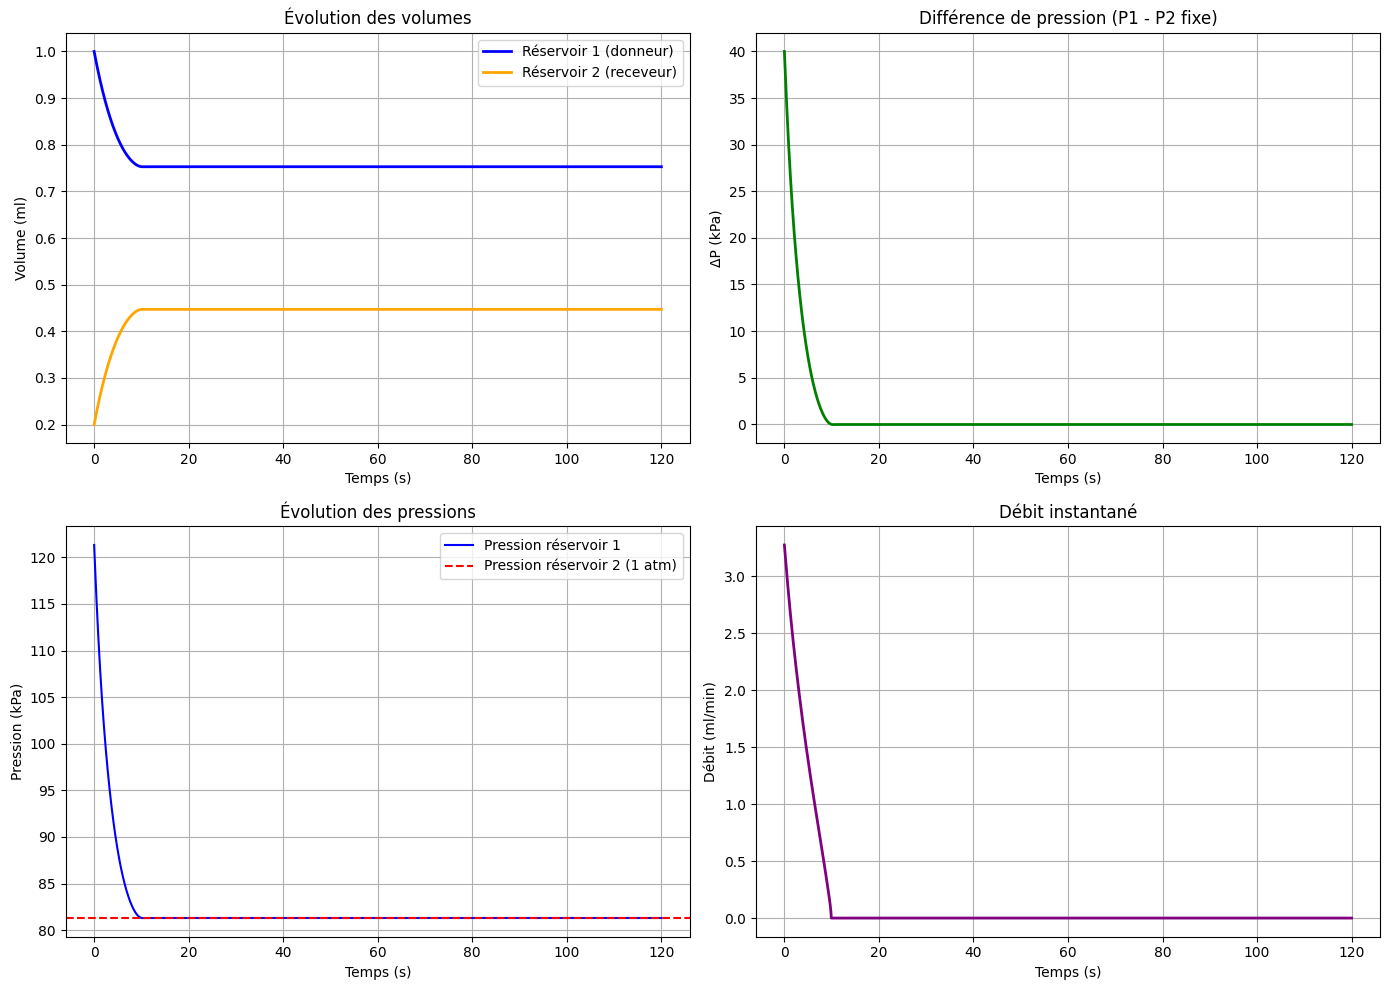

In [94]:
import numpy as np
from scipy.integrate import solve_ivp
import matplotlib.pyplot as plt

# ====================== PARAMÈTRES RECOMMANDÉS POUR ~90% ======================
rho = 1050.0
Cd = 0.65
D_orifice = 3.5                 # ← 3.5 mm recommandé
A = np.pi * (D_orifice / 2000)**2

V_tank = 0.0015
V1_init = 0.0010                # 1000 ml
V2_init = 0.0002                # 200 ml

P_atm = 101325.0
P1_init = P_atm + 20000         # +14 kPa (bon réglage)

P2_fixed = P_atm - 20000               # venting à l'air libre

# ====================== FONCTION ======================
def transfert(t, y, A, rho, Cd, V_tank, P2_fixed):
    V1, P1, V2 = y
    V1 = max(0.0, min(V1, V_tank))
    V2 = max(0.0, min(V2, V_tank))
    V_gas1 = V_tank - V1
    
    deltaP = P1 - P2_fixed
    Q = 0.0
    if deltaP > 10 and V1 > 0.00001:
        Q = Cd * A * np.sqrt(2 * deltaP / rho)
    if V1 < 0.00003:
        Q = min(Q, V1 / 0.01)
    
    dV1_dt = -Q
    dV2_dt = +Q
    dP1_dt = - (P1 / V_gas1) * Q if V_gas1 > 1e-8 else 0
    
    return [dV1_dt, dP1_dt, dV2_dt]

# Simulation
y0 = [V1_init, P1_init, V2_init]
sol = solve_ivp(transfert, (0, 120), y0, args=(A, rho, Cd, V_tank, P2_fixed),
                method='LSODA', t_eval=np.linspace(0, 120, 1500))

volume_transfere = (sol.y[2][-1] - V2_init) * 1000
print(f"Volume transféré : {volume_transfere:.1f} ml  →  {volume_transfere/10:.1f} %")

# ====================== RÉSULTATS ======================
volume_transfere = (sol.y[2][-1] - V2_init) * 1000
print(f"Volume transféré final : {volume_transfere:.1f} ml")
print(f"Pression finale réservoir 1 : {sol.y[1][-1]/1000:.2f} kPa")
print(f"Pression réservoir 2 (fixe) : {P2_fixed/1000:.2f} kPa")

# ====================== GRAPHIOUES ======================
plt.figure(figsize=(14, 10))

plt.subplot(2, 2, 1)
plt.plot(sol.t, sol.y[0]*1000, label='Réservoir 1 (donneur)', color='blue', linewidth=2)
plt.plot(sol.t, sol.y[2]*1000, label='Réservoir 2 (receveur)', color='orange', linewidth=2)
plt.xlabel('Temps (s)')
plt.ylabel('Volume (ml)')
plt.title('Évolution des volumes')
plt.legend()
plt.grid(True)

plt.subplot(2, 2, 2)
deltaP = sol.y[1] - P2_fixed
plt.plot(sol.t, deltaP/1000, 'g', linewidth=2)
plt.xlabel('Temps (s)')
plt.ylabel('ΔP (kPa)')
plt.title('Différence de pression (P1 - P2 fixe)')
plt.grid(True)

plt.subplot(2, 2, 3)
plt.plot(sol.t, sol.y[1]/1000, label='Pression réservoir 1', color='blue')
plt.axhline(y=P2_fixed/1000, color='red', linestyle='--', label='Pression réservoir 2 (1 atm)')
plt.xlabel('Temps (s)')
plt.ylabel('Pression (kPa)')
plt.title('Évolution des pressions')
plt.legend()
plt.grid(True)

plt.subplot(2, 2, 4)
debit = Cd * A * np.sqrt(2 * np.maximum(sol.y[1] - P2_fixed, 0) / rho) * 1000 * 60
plt.plot(sol.t, debit, 'purple', linewidth=2)
plt.xlabel('Temps (s)')
plt.ylabel('Débit (ml/min)')
plt.title('Débit instantané')
plt.grid(True)

plt.tight_layout()
plt.show()

0
0.0002691612717314187
1
0.0002691612717314187
2
0.0002691612717314187
3
0.0002691612717314187
4
0.0002691612717314187
Volume total transféré après 5 cycles : 0.1 ml
Pourcentage transféré : 0.0 %


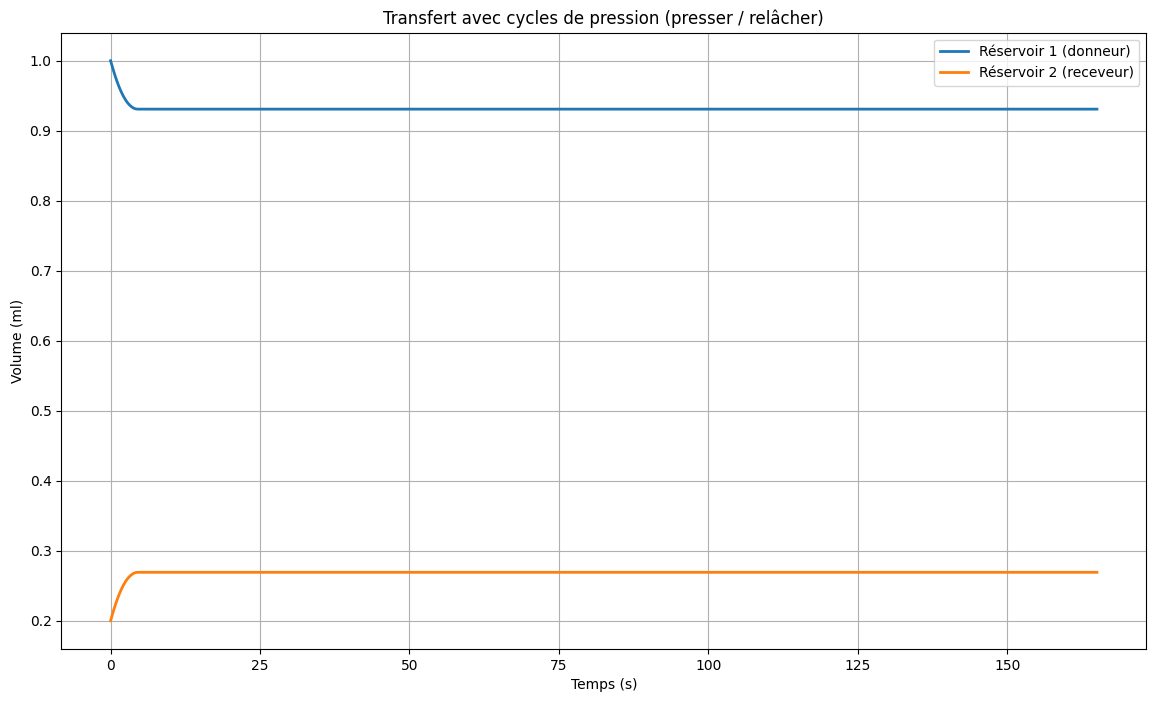

In [99]:
import numpy as np
from scipy.integrate import solve_ivp
import matplotlib.pyplot as plt

# ====================== PARAMÈTRES ======================
rho = 1050.0
Cd = 0.65
D_orifice = 3.5e-3               # 3.5 mm
A = np.pi * (D_orifice / 2)**2

V_tank = 0.0015
V1_init = 0.0010                 # 1000 ml
V2_init = 0.0002

P_atm = 101325.0
P2_fixed = P_atm                 # réservoir 2 venté

# Paramètres des cycles de pression
pression_max = 14000             # surpression maximale quand on presse (+14 kPa)
nb_cycles = 5                    # nombre de fois qu'on presse
duree_pression = 25              # durée pendant laquelle on maintient la pression (secondes)
duree_relache = 8                # durée pendant laquelle on relâche (air entre)

# ====================== FONCTION ======================
def transfert(t, y, A, rho, Cd, V_tank, P2_fixed, est_presse):
    V1, P1, V2 = y
    V1 = max(0.0, min(V1, V_tank))
    V2 = max(0.0, min(V2, V_tank))
    V_gas1 = V_tank - V1
    
    # Pression cible selon si on presse ou non
    P1_cible = P_atm + pression_max if est_presse else P_atm
    
    deltaP = P1 - P2_fixed
    Q = 0.0
    if deltaP > 10 and V1 > 0.00001:
        Q = Cd * A * np.sqrt(2 * deltaP / rho)
    
    if V1 < 0.00003:
        Q = min(Q, V1 / 0.01)
    
    dV1_dt = -Q
    dV2_dt = +Q
    dP1_dt = - (P1 / V_gas1) * Q if V_gas1 > 1e-8 else 0
    
    return [dV1_dt, dP1_dt, dV2_dt]

# ====================== SIMULATION PAR CYCLES ======================
t_total = 0
t_points = []
V1_points = []
V2_points = []
P1_points = []
Q_points = []

V1 = V1_init
P1 = P_atm + pression_max
V2 = V2_init

for cycle in range(nb_cycles):
    # Phase 1 : On presse
    print(cycle)
    est_presse = True
    y0 = [V1, P1, V2]
    sol = solve_ivp(transfert, (t_total, t_total + duree_pression), y0,
                    args=(A, rho, Cd, V_tank, P2_fixed, est_presse),
                    method='LSODA', t_eval=np.linspace(t_total, t_total + duree_pression, 300))
    
    V1 = sol.y[0][-1]
    P1 = sol.y[1][-1]
    V2 = sol.y[2][-1]
    print(V2)
    
    t_points.extend(sol.t)
    V1_points.extend(sol.y[0])
    V2_points.extend(sol.y[2])
    P1_points.extend(sol.y[1])
    
    t_total += duree_pression
    
    # Phase 2 : On relâche (reventilation)
    est_presse = False
    y0 = [V1, P1, V2]
    sol_rel = solve_ivp(transfert, (t_total, t_total + duree_relache), y0,
                        args=(A, rho, Cd, V_tank, P2_fixed, est_presse),
                        method='LSODA', t_eval=np.linspace(t_total, t_total + duree_relache, 200))
    
    V1 = sol_rel.y[0][-1]
    P1 = sol_rel.y[1][-1]
    V2 = sol_rel.y[2][-1]
    
    t_points.extend(sol_rel.t)
    V1_points.extend(sol_rel.y[0])
    V2_points.extend(sol_rel.y[2])
    P1_points.extend(sol_rel.y[1])
    
    t_total += duree_relache

# ====================== AFFICHAGE ======================
volume_transfere = (V2 - V2_init) * 1000
print(f"Volume total transféré après {nb_cycles} cycles : {volume_transfere:.1f} ml")
print(f"Pourcentage transféré : {volume_transfere / 10:.1f} %")

plt.figure(figsize=(14, 8))
plt.plot(t_points, np.array(V1_points)*1000, label='Réservoir 1 (donneur)', linewidth=2)
plt.plot(t_points, np.array(V2_points)*1000, label='Réservoir 2 (receveur)', linewidth=2)
plt.xlabel('Temps (s)')
plt.ylabel('Volume (ml)')
plt.title('Transfert avec cycles de pression (presser / relâcher)')
plt.legend()
plt.grid(True)
plt.show()

Cycle 1
20 0.000327987684649287
Cycle 2
20 0.0004529371083321377
Cycle 3
20 0.0005788747490220263
Cycle 4
20 0.0007055486061852489
Cycle 5
20 0.0008327913367334095
Cycle 6
20 0.0009604863801813428

Volume total transféré après 6 cycles : 0.8 ml  (0.1 %)


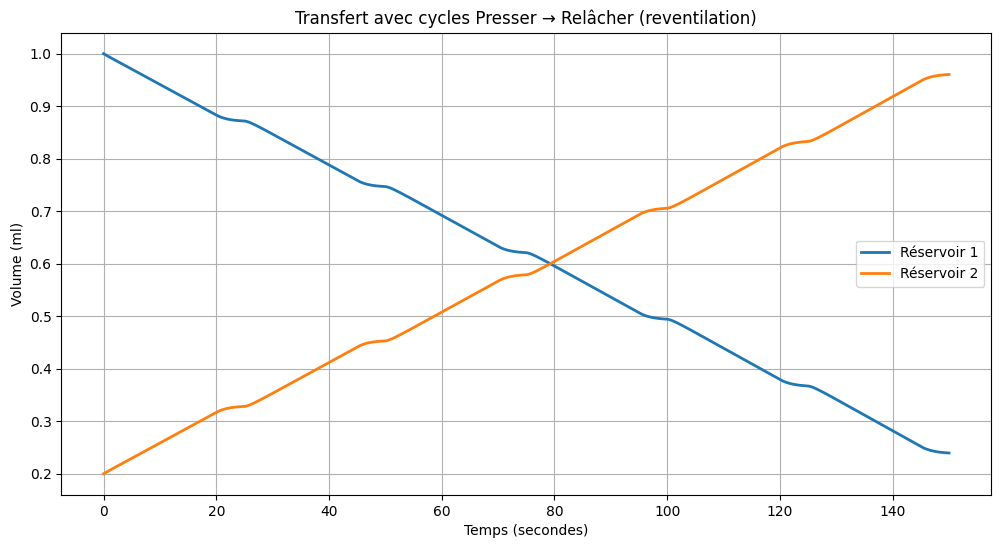

In [103]:
import numpy as np
from scipy.integrate import solve_ivp
import matplotlib.pyplot as plt

# ====================== PARAMÈTRES ======================
rho = 1050.0
Cd = 0.65
D_orifice = 1.5e-3                  # 3.5 mm
A = np.pi * (D_orifice / 2)**2

V_tank = 0.0015
V1_init = 0.0010
V2_init = 0.0002

P_atm = 101325.0
P2_fixed = P_atm
pression_max = 15000                # surpression quand on presse

nb_cycles = 6
duree_pression = 20
duree_relache = 5

# ====================== FONCTION ======================
def transfert(t, y, A, rho, Cd, V_tank, P2_fixed, est_presse):
    V1, P1, V2 = y
    V1 = max(0.0, min(V1, V_tank))
    V2 = max(0.0, min(V2, V_tank))
    V_gas1 = V_tank - V1
    
    # Pression cible selon la phase
    if est_presse:
        P_cible = P_atm + pression_max
    else:
        P_cible = P_atm                     # on reventile à 1 atm
    
    deltaP = P1 - P2_fixed
    Q = 0.0
    if deltaP > 10 and V1 > 0.00001:
        Q = Cd * A * np.sqrt(2 * deltaP / rho)
    
    if V1 < 0.00003:
        Q = min(Q, V1 / 0.01)
    
    dV1_dt = -Q
    dV2_dt = +Q
    
    # Évolution de la pression + relaxation vers la cible pendant la phase
    dP1_dt = - (P1 / V_gas1) * Q if V_gas1 > 1e-8 else 0
    # Ajout d'un terme de relaxation (comme si l'air entre/sort)
    relaxation = 0.8 * (P_cible - P1)      # constante de temps rapide
    dP1_dt += relaxation
    
    return [dV1_dt, dP1_dt, dV2_dt]

# ====================== SIMULATION ======================
t_total = 0.0
t_points = []
V1_points = []
V2_points = []
P1_points = []

V1 = V1_init
P1 = P_atm + pression_max
V2 = V2_init

for cycle in range(nb_cycles):
    print(f"Cycle {cycle+1}")
    
    # Phase 1 : Presser
    y0 = [V1, P1, V2]
    sol = solve_ivp(transfert, (t_total, t_total + duree_pression), y0,
                    args=(A, rho, Cd, V_tank, P2_fixed, True),
                    method='LSODA', dense_output=True)
    
    t_new = np.linspace(t_total, t_total + duree_pression, 300)
    y_new = sol.sol(t_new)
    
    t_points.extend(t_new)
    V1_points.extend(y_new[0])
    V2_points.extend(y_new[2])
    P1_points.extend(y_new[1])
    
    V1, P1, V2 = y_new[0][-1], y_new[1][-1], y_new[2][-1]
    t_total += duree_pression
    
    # Phase 2 : Relâcher (reventiler)
    y0 = [V1, P1, V2]
    sol_rel = solve_ivp(transfert, (t_total, t_total + duree_relache), y0,
                        args=(A, rho, Cd, V_tank, P2_fixed, False),
                        method='LSODA', dense_output=True)
    
    t_new = np.linspace(t_total, t_total + duree_relache, 150)
    y_new = sol_rel.sol(t_new)
    
    t_points.extend(t_new)
    V1_points.extend(y_new[0])
    V2_points.extend(y_new[2])
    P1_points.extend(y_new[1])
    
    V1, P1, V2 = y_new[0][-1], y_new[1][-1], y_new[2][-1]
    t_total += duree_relache

    
    print(duree_pression, V2)

volume_transfere = (V2 - V2_init) * 1000
print(f"\nVolume total transféré après {nb_cycles} cycles : {volume_transfere:.1f} ml  ({volume_transfere/10:.1f} %)")

# Graphique
plt.figure(figsize=(12, 6))
plt.plot(t_points, np.array(V1_points)*1000, label='Réservoir 1', linewidth=2)
plt.plot(t_points, np.array(V2_points)*1000, label='Réservoir 2', linewidth=2)
plt.xlabel('Temps (secondes)')
plt.ylabel('Volume (ml)')
plt.title('Transfert avec cycles Presser → Relâcher (reventilation)')
plt.legend()
plt.grid(True)
plt.show()

   SIMULATION TRANSFERT SAVON — MULTI-CYCLES AVEC ACCUMULATION D'AIR
 Cycle |  V1 début |    V1 fin |  Transféré |  P1 surpres |   V_gaz1
-----------------------------------------------------------------
     1   |  1000.0 ml |   763.9 ml |    236.1 ml |    +434.2 mbar |  500.0 ml
     2   |   763.9 ml |   547.3 ml |    216.6 ml |    +259.3 mbar |  736.1 ml
     3   |   547.3 ml |   334.8 ml |    212.5 ml |    +189.4 mbar |  952.7 ml
     4   |   334.8 ml |   121.8 ml |    213.0 ml |    +149.7 mbar | 1165.2 ml
     5   |   121.8 ml |     0.1 ml |    121.7 ml |    +123.8 mbar | 1378.2 ml
     6   |     0.1 ml |     0.1 ml |      0.0 ml |    +112.6 mbar | 1499.9 ml
     7   |     0.1 ml |     0.1 ml |      0.0 ml |    +112.6 mbar | 1499.9 ml
     8   |     0.1 ml |     0.1 ml |      0.0 ml |    +112.6 mbar | 1499.9 ml
     9   |     0.1 ml |     0.1 ml |      0.0 ml |    +112.6 mbar | 1499.9 ml
    10   |     0.1 ml |     0.1 ml |      0.0 ml |    +112.6 mbar | 1499.9 ml
----------------

C:\Users\jeand\AppData\Local\Temp\ipykernel_16412\2337201549.py:241: UserWarning: Glyph 128230 (\N{PACKAGE}) missing from font(s) DejaVu Sans.
  plt.savefig('transfert_savon.png', dpi=150, bbox_inches='tight', facecolor=couleur_fond)
C:\Users\jeand\AppData\Local\Temp\ipykernel_16412\2337201549.py:241: UserWarning: Glyph 128168 (\N{DASH SYMBOL}) missing from font(s) DejaVu Sans.
  plt.savefig('transfert_savon.png', dpi=150, bbox_inches='tight', facecolor=couleur_fond)
C:\Users\jeand\AppData\Local\Temp\ipykernel_16412\2337201549.py:241: UserWarning: Glyph 128167 (\N{DROPLET}) missing from font(s) DejaVu Sans.
  plt.savefig('transfert_savon.png', dpi=150, bbox_inches='tight', facecolor=couleur_fond)
C:\Users\jeand\AppData\Local\Temp\ipykernel_16412\2337201549.py:241: UserWarning: Glyph 127788 (\N{WIND BLOWING FACE}) missing from font(s) DejaVu Sans.
  plt.savefig('transfert_savon.png', dpi=150, bbox_inches='tight', facecolor=couleur_fond)


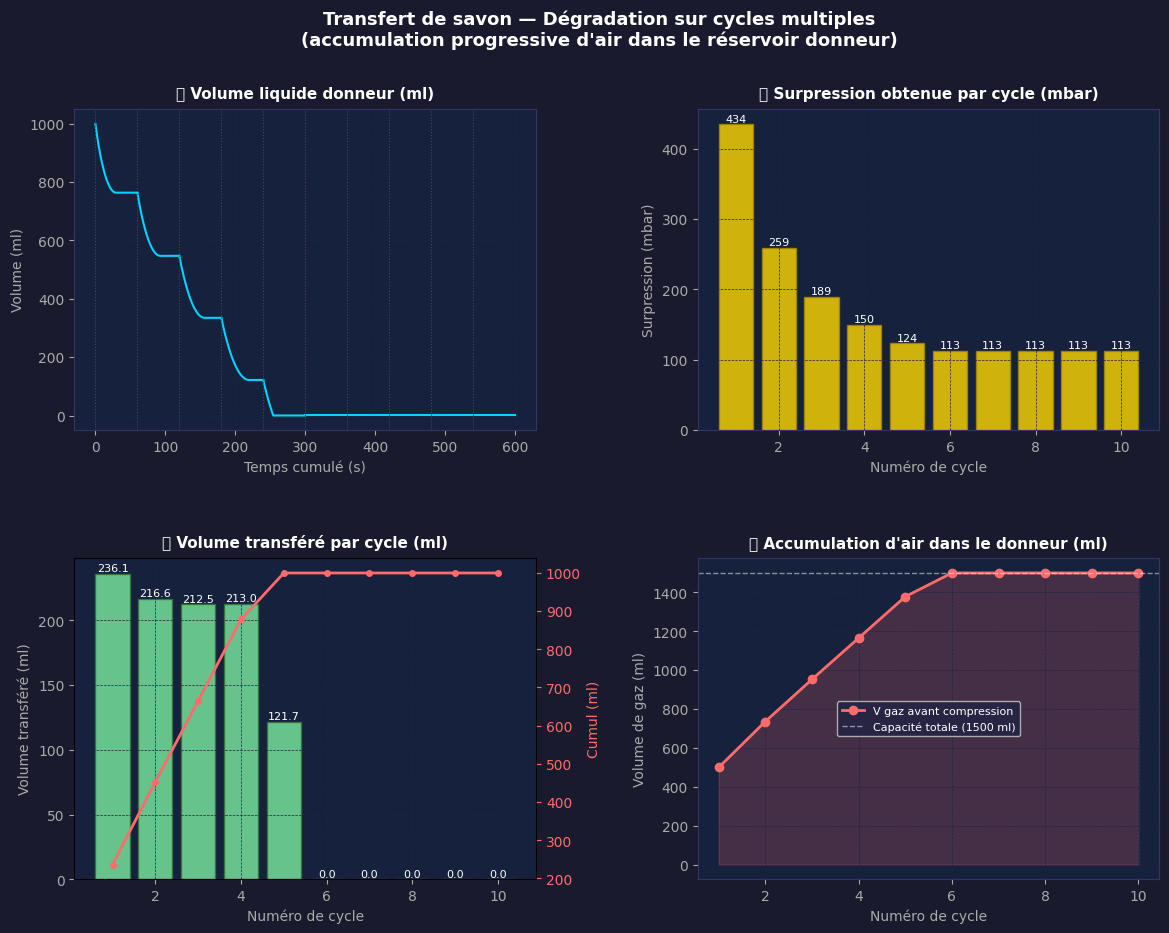


Graphique sauvegardé : transfert_savon.png


In [114]:
import numpy as np
from scipy.integrate import solve_ivp
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec

# ====================== PARAMÈTRES PHYSIQUES ======================
rho         = 1050.0        # densité du savon liquide (kg/m³)
Cd          = 0.62          # coefficient de décharge
D_orifice   = 0.002         # diamètre de l'orifice (m)
A           = np.pi * (D_orifice / 2)**2

V_tank1     = 0.0015        # capacité totale réservoir donneur (m³)
V_tank2     = 0.0015        # capacité totale réservoir receveur (m³)

P_atm       = 101325.0      # pression atmosphérique (Pa)

# Conditions initiales (avant tout cycle)
V1_init     = 0.0010        # 1.0 litre de savon dans le donneur
V2_init     = 0.0002        # 0.2 litre dans le receveur

# ====================== PARAMÈTRE CLÉ : déformation mécanique ======================
# Volume de compression manuelle du flacon donneur (m³)
# Correspond à l'enfoncement physique du flacon par la main
delta_V_compression = 0.00015   # 150 ml de déformation max de la paroi

# Dépression dans le receveur (on presse puis on relâche avant connexion)
delta_P_depression  = 3000.0    # Pa (≈ 30 mbar de dépression)

N_cycles    = 10            # nombre de cycles pression/reventilation
t_cycle     = 60.0          # durée simulée par cycle (secondes)

# ====================== ÉQUATIONS DIFFÉRENTIELLES ======================
def transfert(t, y, A, rho, Cd, V_tank1, V_tank2, P2_init_cycle):
    V1, P1, V2 = y

    V_gas1 = V_tank1 - V1
    V_gas2 = V_tank2 - V2

    deltaP = P1 - P2_init_cycle  # receveur maintenu à sa pression initiale de cycle
    # (le receveur évacue son air → pression constante au cours du temps)
    # Mais ici on prend en compte que le receveur se remplit : P2 monte légèrement
    # Modèle : receveur avec évent partiel → pression receveur constante = P2_init_cycle
    # (hypothèse : évent permet évacuation de l'air entrant)

    if deltaP > 0 and V1 > 1e-7:
        Q = Cd * A * np.sqrt(2 * deltaP / rho)
    else:
        Q = 0.0

    # Limiter le débit si le donneur est presque vide
    Q = min(Q, V1 / 0.01)  # ne pas vider plus vite que 10ms

    dV1_dt = -Q

    # Pression dans le donneur : gaz se détend au fur et à mesure que liquide sort
    # dV_gaz1 = -dV1_dt (gaz augmente quand liquide diminue)
    # P1 * V_gaz1 = cste → dP1/dt = -(P1/V_gaz1) * dV_gaz1/dt = (P1/V_gaz1) * dV1_dt
    dP1_dt = (P1 / V_gas1) * dV1_dt if V_gas1 > 1e-8 else 0.0

    dV2_dt = +Q  # suivi du volume reçu (informatif)

    return [dV1_dt, dP1_dt, dV2_dt]


# ====================== SIMULATION MULTI-CYCLES ======================
# Historique
historique = {
    'cycle'         : [],
    'V1_debut'      : [],
    'V1_fin'        : [],
    'V2_debut'      : [],
    'V2_fin'        : [],
    'V_transfere'   : [],
    'P1_surpression': [],
    'P2_depression' : [],
    'V_gaz1_debut'  : [],
    't'             : [],   # temps absolu
    'V1_t'          : [],   # volume donneur au cours du temps
    'P1_t'          : [],   # pression donneur au cours du temps
    'debit_t'       : [],
}

V1_courant  = V1_init
V2_courant  = V2_init
t_absolu    = 0.0

print("=" * 65)
print("   SIMULATION TRANSFERT SAVON — MULTI-CYCLES AVEC ACCUMULATION D'AIR")
print("=" * 65)
print(f"{'Cycle':>6} | {'V1 début':>9} | {'V1 fin':>9} | {'Transféré':>10} | {'P1 surpres':>11} | {'V_gaz1':>8}")
print("-" * 65)

for i in range(N_cycles):
    # --- Volume de gaz dans le donneur AVANT compression ---
    V_gaz1_avant = V_tank1 - V1_courant

    # --- Surpression obtenue par compression manuelle ---
    # On réduit le volume de gaz de delta_V_compression
    # Loi de Boyle : P1 * V_gaz1 = P_atm * (V_gaz1 - delta_V_compression)
    V_gaz1_comprime = V_gaz1_avant - delta_V_compression
    if V_gaz1_comprime <= 0:
        print(f"Cycle {i+1:2d} : plus de place pour comprimer ! Arrêt.")
        break
    P1_surpression = P_atm * V_gaz1_avant / V_gaz1_comprime

    # --- Dépression dans le receveur ---
    P2_depression = P_atm - delta_P_depression

    # --- Conditions initiales du cycle ---
    y0 = [V1_courant, P1_surpression, V2_courant]

    # --- Intégration ---
    sol = solve_ivp(
        transfert,
        t_span=(0, t_cycle),
        y0=y0,
        args=(A, rho, Cd, V_tank1, V_tank2, P2_depression),
        method='RK45',
        t_eval=np.linspace(0, t_cycle, 1000),
        rtol=1e-7,
        atol=1e-10,
    )

    V1_fin      = sol.y[0][-1]
    V2_fin      = sol.y[2][-1]
    V_transfere = V1_courant - V1_fin

    # Débit instantané
    deltaP_t = np.maximum(sol.y[1] - P2_depression, 0)
    debit_t  = Cd * A * np.sqrt(2 * deltaP_t / rho) * 1e6 * 60  # ml/min

    # Stocker historique temporel
    historique['t'].append(sol.t + t_absolu)
    historique['V1_t'].append(sol.y[0] * 1e6)   # en ml
    historique['P1_t'].append(sol.y[1] / 1000)   # en kPa
    historique['debit_t'].append(debit_t)

    # Stocker résumé cycle
    historique['cycle'].append(i + 1)
    historique['V1_debut'].append(V1_courant * 1e6)
    historique['V1_fin'].append(V1_fin * 1e6)
    historique['V2_debut'].append(V2_courant * 1e6)
    historique['V2_fin'].append(V2_fin * 1e6)
    historique['V_transfere'].append(V_transfere * 1e6)
    historique['P1_surpression'].append((P1_surpression - P_atm) / 100)  # mbar
    historique['P2_depression'].append(delta_P_depression / 100)         # mbar
    historique['V_gaz1_debut'].append(V_gaz1_avant * 1e6)

    print(f"  {i+1:4d}   | {V1_courant*1e6:7.1f} ml | {V1_fin*1e6:7.1f} ml | "
          f"{V_transfere*1e6:8.1f} ml | {(P1_surpression-P_atm)/100:+9.1f} mbar | "
          f"{V_gaz1_avant*1e6:6.1f} ml")

    # --- Reventilation : le donneur revient à P_atm, l'air entre ---
    # Le volume de gaz reste V_gaz1_avant (le flacon reprend sa forme)
    # Mais maintenant il contient plus d'air (le liquide transféré n'est plus là)
    V1_courant = V1_fin
    V2_courant = V2_fin
    t_absolu  += t_cycle

print("-" * 65)
print(f"  TOTAL transféré : {sum(historique['V_transfere']):.1f} ml")
print(f"  Volume résiduel dans le donneur : {V1_courant*1e6:.1f} ml")
print("=" * 65)

# ====================== GRAPHIQUES ======================
fig = plt.figure(figsize=(14, 10))
fig.patch.set_facecolor('#1a1a2e')
gs  = gridspec.GridSpec(2, 2, figure=fig, hspace=0.4, wspace=0.35)

couleur_fond  = '#1a1a2e'
couleur_panel = '#16213e'
couleur1      = '#00d4ff'
couleur2      = '#ff6b6b'
couleur3      = '#ffd700'
couleur4      = '#7bed9f'

def style_ax(ax, titre):
    ax.set_facecolor(couleur_panel)
    ax.set_title(titre, color='white', fontsize=11, fontweight='bold', pad=8)
    ax.tick_params(colors='#aaaaaa')
    ax.xaxis.label.set_color('#aaaaaa')
    ax.yaxis.label.set_color('#aaaaaa')
    for spine in ax.spines.values():
        spine.set_edgecolor('#333366')
    ax.grid(True, color='#222244', linewidth=0.5, linestyle='--')

# --- Graphique 1 : Volume donneur au fil du temps ---
ax1 = fig.add_subplot(gs[0, 0])
style_ax(ax1, '📦 Volume liquide donneur (ml)')
for i in range(len(historique['t'])):
    t = historique['t'][i]
    v = historique['V1_t'][i]
    ax1.plot(t, v, color=couleur1, linewidth=1.5)
    ax1.axvline(t[0], color='#444466', linewidth=0.8, linestyle=':')
ax1.set_xlabel('Temps cumulé (s)')
ax1.set_ylabel('Volume (ml)')

# --- Graphique 2 : Surpression par cycle ---
ax2 = fig.add_subplot(gs[0, 1])
style_ax(ax2, '💨 Surpression obtenue par cycle (mbar)')
cycles = historique['cycle']
surpressions = historique['P1_surpression']
bars = ax2.bar(cycles, surpressions, color=couleur3, alpha=0.8, edgecolor='#aa8800')
ax2.set_xlabel('Numéro de cycle')
ax2.set_ylabel('Surpression (mbar)')
for bar, val in zip(bars, surpressions):
    ax2.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.3,
             f'{val:.0f}', ha='center', va='bottom', color='white', fontsize=8)

# --- Graphique 3 : Volume transféré par cycle ---
ax3 = fig.add_subplot(gs[1, 0])
style_ax(ax3, '💧 Volume transféré par cycle (ml)')
bars3 = ax3.bar(cycles, historique['V_transfere'], color=couleur4, alpha=0.8, edgecolor='#337733')
ax3.set_xlabel('Numéro de cycle')
ax3.set_ylabel('Volume transféré (ml)')
cumul = np.cumsum(historique['V_transfere'])
ax3b = ax3.twinx()
ax3b.plot(cycles, cumul, color=couleur2, linewidth=2, marker='o', markersize=4, label='Cumul')
ax3b.set_ylabel('Cumul (ml)', color=couleur2)
ax3b.tick_params(colors=couleur2)
for bar, val in zip(bars3, historique['V_transfere']):
    ax3.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.2,
             f'{val:.1f}', ha='center', va='bottom', color='white', fontsize=8)

# --- Graphique 4 : Volume de gaz accumulé ---
ax4 = fig.add_subplot(gs[1, 1])
style_ax(ax4, '🌬️ Accumulation d\'air dans le donneur (ml)')
ax4.plot(cycles, historique['V_gaz1_debut'], color=couleur2, linewidth=2,
         marker='o', markersize=6, label="V gaz avant compression")
ax4.fill_between(cycles, historique['V_gaz1_debut'], alpha=0.2, color=couleur2)
ax4.axhline(V_tank1 * 1e6, color='white', linewidth=1, linestyle='--', alpha=0.5,
            label=f'Capacité totale ({V_tank1*1e6:.0f} ml)')
ax4.set_xlabel('Numéro de cycle')
ax4.set_ylabel('Volume de gaz (ml)')
ax4.legend(facecolor='#222244', labelcolor='white', fontsize=8)

fig.suptitle('Transfert de savon — Dégradation sur cycles multiples\n'
             '(accumulation progressive d\'air dans le réservoir donneur)',
             color='white', fontsize=13, fontweight='bold', y=0.98)

plt.savefig('transfert_savon.png', dpi=150, bbox_inches='tight', facecolor=couleur_fond)
plt.show()
print("\nGraphique sauvegardé : transfert_savon.png")